[nltk_data] Downloading package stopwords to C:\Users\Monu
[nltk_data]     Chaurasia\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Data Shape: (49, 2)
sentiment
positive    45
negative     4
Name: count, dtype: int64

--- Logistic Regression ---
Accuracy: 0.9
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
    positive       0.90      1.00      0.95         9

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10


--- Naive Bayes ---
Accuracy: 0.9
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         1
    positive       0.90      1.00      0.95         9

    accuracy                           0.90        10
   macro avg       0.45      0.50      0.47        10
weighted avg       0.81      0.90      0.85        10



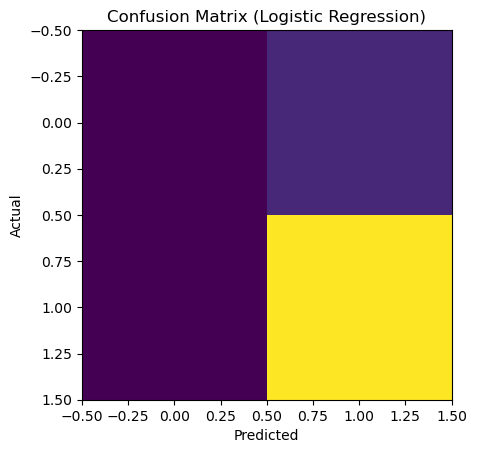


Sample Prediction: ['positive']


In [18]:
# ================== IMPORT LIBRARIES ==================
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

# Download stopwords
nltk.download('stopwords')

# ================== LOAD DATASET ==================
df = pd.read_csv("Sentiment dataset.csv")

# Convert columns to lowercase
df.columns = df.columns.str.lower()

# Clean sentiment values
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()

# Keep only positive & negative
df = df[df['sentiment'].isin(['positive', 'negative'])]

# Keep required columns
df = df[['text', 'sentiment']]

print("Data Shape:", df.shape)
print(df['sentiment'].value_counts())

# ================== TEXT PREPROCESSING ==================
ps = PorterStemmer()
corpus = []

for i in range(len(df)):
    review = re.sub('[^a-zA-Z]', ' ', df['text'].iloc[i])
    review = review.lower().split()
    
    review = [ps.stem(word) for word in review if word not in stopwords.words('english')]
    review = ' '.join(review)
    
    corpus.append(review)

# ================== TF-IDF ==================
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(corpus).toarray()

y = df['sentiment']

# ================== TRAIN TEST SPLIT ==================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ================== LOGISTIC REGRESSION ==================
lr_model = LogisticRegression(max_iter=300)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr, zero_division=0))

# ================== NAIVE BAYES ==================
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("\n--- Naive Bayes ---")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb, zero_division=0))

# ================== CONFUSION MATRIX ==================
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ================== SAMPLE PREDICTION ==================
sample = ["This is a very bad day"]

sample_clean = re.sub('[^a-zA-Z]', ' ', sample[0]).lower().split()
sample_clean = [ps.stem(word) for word in sample_clean if word not in stopwords.words('english')]
sample_clean = ' '.join(sample_clean)

sample_vec = tfidf.transform([sample_clean]).toarray()

print("\nSample Prediction:", lr_model.predict(sample_vec))